# Inteligência Artificial Aplicada à Esclerose Múltipla: Preditores de Progressão e Estilo de Vida - Capítulo 2

## 1. Criando os dados sintéticos

In [ ]:
import pandas as pd
import numpy as np
# Fazendo os resultados serem os mesmos toda vez que rodar o código
np.random.seed(42)
# Simulando um grupo de 500 pacientes
n_pacientes = 500
# GERANDO O HISTÓRICO DE ESTILO DE VIDA
idade = np.random.randint(20, 65, n_pacientes)
fumante = np.random.choice([0, 1], p=[0.8, 0.2], size=n_pacientes) # 20% são fumantes
vitamina_d = np.random.randint(10, 70, n_pacientes) # Níveis de 10 a 70
estresse = np.random.randint(1, 11, n_pacientes) # Escala de 1 a 10
exercicio = np.random.randint(0, 8, n_pacientes) # Dias por semana (0 a 7)
poluicao = np.random.randint(20, 150, n_pacientes) # Índice de Qualidade do Ar (AQI)
# Outras variáveis
horas_sono = np.random.normal(7, 1.5, n_pacientes).round(1) 
qualidade_sono = np.random.randint(1, 11, n_pacientes) # Nota de 1 (Péssimo) a 10 (Excelente)
outra_autoimune = np.random.choice([0, 1], p=[0.85, 0.15], size=n_pacientes) # 15% têm outra doença autoimune
# CALCULANDO O RISCO DE PIORA
risco = 0.05 
# Fatores que aumentam o risco
risco += fumante * 0.30
risco += outra_autoimune * 0.20                    
risco += (estresse / 10) * 0.15
risco += (poluicao / 150) * 0.10
# Influência do sono
risco += np.where(horas_sono < 6, 0.10, 0)         # Dormir menos de 6h aumenta o risco
risco += ((10 - qualidade_sono) / 10) * 0.15       # Qualidade ruim aumenta o risco
# fatores protetores
risco -= (vitamina_d / 70) * 0.20
risco -= (exercicio / 7) * 0.15
# Garantindo que a probabilidade fique dentro dos limites reais (entre 2% e 95%)
risco = np.clip(risco, 0.02, 0.95)
# Criando o DataFrame
houve_progressao = np.random.binomial(1, risco)
df_estilo = pd.DataFrame({
    'Idade': idade,
    'Fumante_0_1': fumante,
    'Outra_Autoimune_0_1': outra_autoimune,
    'Vitamina_D_ng_mL': vitamina_d,
    'Nivel_Estresse_1_10': estresse,
    'Exercicio_Dias_Semana': exercicio,
    'Poluicao_Ar_AQI': poluicao,
    'Horas_Sono': horas_sono,
    'Qualidade_Sono_1_10': qualidade_sono,
    'Houve_Progressao': houve_progressao
})
# Salvando o DataFrame em um arquivo CSV
nome_arquivo = 'dados_estilo_vida_simulados_v2.csv'
df_estilo.to_csv(nome_arquivo, index=False)
print(f"A tabela foi salva como '{nome_arquivo}'.")
print("\n📊 Primeiras linhas dos pacientes:")
display(df_estilo.head())

A tabela foi salva como 'dados_estilo_vida_simulados_v2.csv'.

📊 Primeiras linhas dos pacientes:


,Idade,Fumante_0_1,Outra_Autoimune_0_1,Vitamina_D_ng_mL,Nivel_Estresse_1_10,Exercicio_Dias_Semana,Poluicao_Ar_AQI,Horas_Sono,Qualidade_Sono_1_10,Houve_Progressao
0,58,0,0,42,2,3,47,6.8,7,0
1,48,0,0,32,8,0,70,8.0,10,0
2,34,0,0,64,3,1,24,7.3,10,0
3,62,0,0,37,10,0,24,5.9,2,1
4,27,0,0,41,3,6,113,6.5,9,0


### Criando o Mapa de Calor

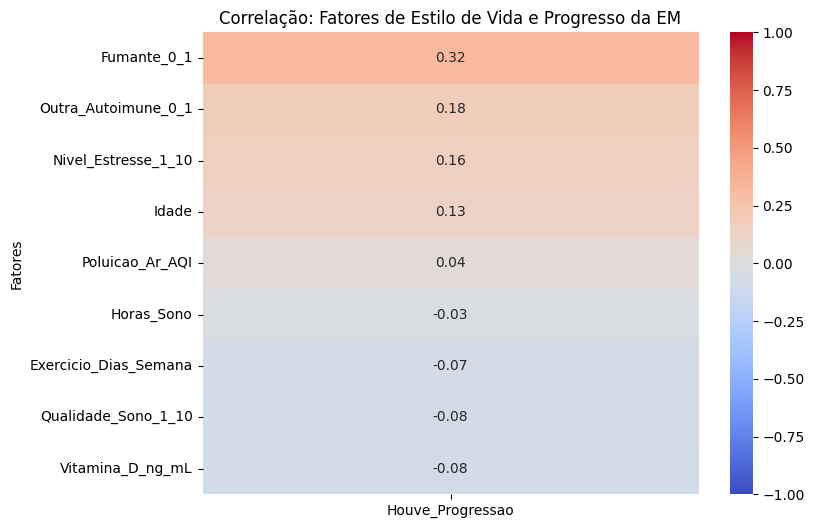

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
# Calculando a correlação
correlacao_estilovida = df_estilo.corr()
# Focando apenas no que causa a piora 
alvo_corr_estilo = correlacao_estilovida[['Houve_Progressao']].sort_values(by='Houve_Progressao', ascending=False)
# Retirando a coluna de progressão
alvo_corr_estilo = alvo_corr_estilo.drop('Houve_Progressao')
# Desenhando o gráfico
plt.figure(figsize=(8, 6))
sns.heatmap(alvo_corr_estilo, vmin=-1, vmax=1, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlação: Fatores de Estilo de Vida e Progresso da EM', fontsize=12)
plt.ylabel('Fatores')
plt.show()